<a href="https://colab.research.google.com/github/sastha-06/24ADI003_ML_LAB/blob/main/24BAD106_ML_EXP5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SCENARIO 1: K-Nearest Neighbors (KNN)
Tumor Classification using Breast Cancer Dataset

Step 1:
I import all required Python libraries. Pandas and NumPy are used for data handling, Matplotlib and Seaborn are used for visualization, and Scikit-learn modules are used for preprocessing, model training, and evaluation.

Step 2:
I load the Breast Cancer dataset. The dataset contains medical measurements of tumors. Important input features such as radius, texture, perimeter, area, and smoothness are selected as input variables. The target variable represents tumor diagnosis (Benign or Malignant).

Step 3:
I perform data inspection and preprocessing by checking dataset structure, viewing sample records, and verifying missing values to ensure the dataset is clean and suitable for model training.

Step 4:
I encode the target labels where Benign tumors are converted to 0 and Malignant tumors are converted to 1 since machine learning algorithms require numerical target values.

Step 5:
I apply feature scaling using StandardScaler because KNN is a distance-based algorithm. Scaling ensures all features contribute equally during distance calculation.

Step 6:
I split the dataset into training data (80%) and testing data (20%). The training dataset is used to train the model, while the testing dataset is used to evaluate performance.

Step 7:
I create and train the K-Nearest Neighbors (KNN) classifier using a selected value of K (number of neighbors).

Step 8:
I experiment with different values of K to observe how model performance changes and to identify the optimal K value.

Step 9:
I predict tumor diagnosis labels for the testing dataset using the trained KNN model.

Step 10:
I evaluate model performance using Accuracy, Precision, Recall, and F1 Score to measure classification effectiveness.

Step 11:
I generate a confusion matrix to analyze True Positives, True Negatives, False Positives, and False Negatives, and visualize it using a heatmap.

Step 12:
I analyze misclassified samples to understand incorrect predictions made by the model.

Step 13:
I analyze model sensitivity to different K values using an Accuracy vs K graph.

Step 14:
I visualize the decision boundary using selected features to understand how the KNN algorithm separates benign and malignant tumors.

SASTHA JEYASRI A
24BAD106
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst 

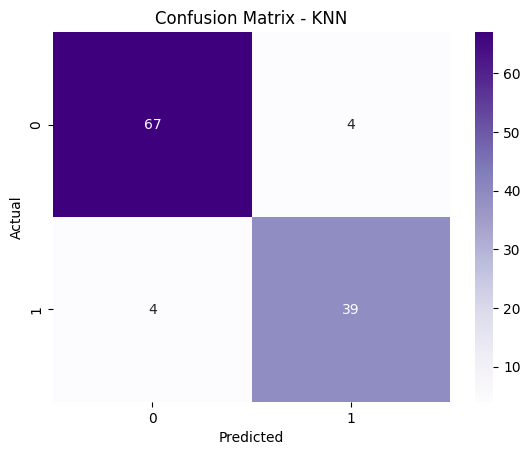

Misclassified Samples: 8


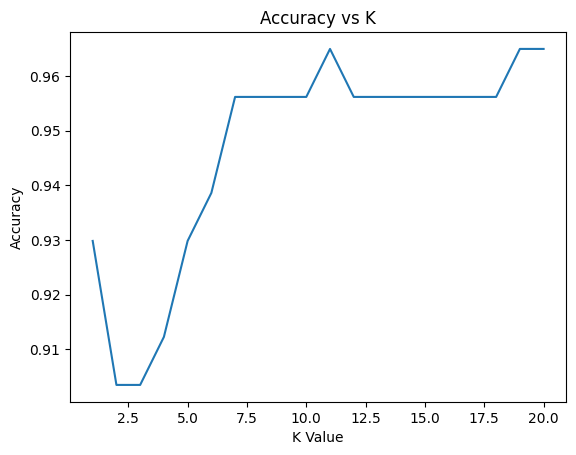

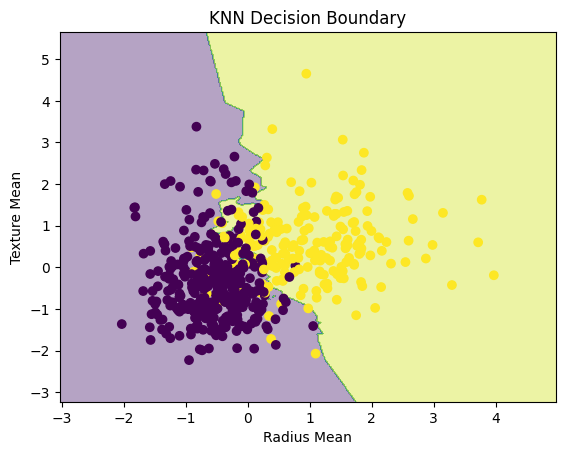

In [ ]:
#from google.colab import files
#uploaded=files.upload()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("SASTHA JEYASRI A\n24BAD106")
data = pd.read_csv("breast-cancer.csv")
print(data.head())
print(data.info())
print(data.isnull().sum())
le = LabelEncoder()
data['diagnosis'] = le.fit_transform(data['diagnosis'])

X = data[['radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean']]
y = data['diagnosis']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d',cmap="Purples")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
misclassified = np.where(y_test != y_pred)
print("Misclassified Samples:", len(misclassified[0]))
accuracy = []

k_range = range(1,21)

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracy.append(accuracy_score(y_test, pred))

plt.plot(k_range, accuracy)
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()

# Select only two features
X2 = data[['radius_mean', 'texture_mean']]
y = data['diagnosis']

# Feature scaling
scaler = StandardScaler()
X2 = scaler.fit_transform(X2)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.2, random_state=42)

# Train KNN model
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Create mesh grid
x_min, x_max = X2[:,0].min()-1, X2[:,0].max()+1
y_min, y_max = X2[:,1].min()-1, X2[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predict boundary
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X2[:,0], X2[:,1], c=y)

plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.title("KNN Decision Boundary")
plt.show()

SCENARIO 2: Decision Tree Algorithm
Loan Approval Prediction using Loan Dataset

Step 1:
I import all required Python libraries. NumPy and Pandas are used for data handling, Matplotlib and Seaborn are used for visualization, and Scikit-learn modules are used for model training and evaluation.

Step 2:
I load the loan dataset using pandas. The dataset contains applicant details such as income, loan amount, credit history, education level, property area, and loan approval status.

Step 3:
I perform data inspection by checking the dataset preview and identifying missing values to understand data quality.

Step 4:
I handle missing values using forward fill method to replace empty entries and maintain dataset consistency.

Step 5:
I encode categorical variables such as Education, Property Area, and Loan Status into numerical values using Label Encoding since machine learning models require numerical inputs.

Step 6:
I select important input features including Applicant Income, Loan Amount, Credit History, Education, and Property Area. The target variable is Loan Status which indicates whether the loan is approved or rejected.

Step 7:
I split the dataset into training data (80%) and testing data (20%) to train and evaluate the model effectively.

Step 8:
I create and train the Decision Tree classifier with a specified tree depth to control model complexity.

Step 9:
I predict loan approval status for the testing dataset using the trained Decision Tree model.

Step 10:
I evaluate model performance using Accuracy, Precision, Recall, and F1 Score to measure classification performance.

Step 11:
I generate a confusion matrix to analyze correct and incorrect predictions and visualize it using a heatmap.

Step 12:
I analyze feature importance to understand which input attributes contribute most to loan approval decisions.

Step 13:
I visualize the Decision Tree structure to understand how decisions are made at each node.

Step 14:
I experiment with different tree depth values to analyze model behavior and detect overfitting or underfitting.

Step 15:
I compare training accuracy and testing accuracy using a depth vs accuracy graph to study shallow and deep tree performance.

SASTHA JEYASRI A
24BAD106
Dataset Preview:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0      

/tmp/ipython-input-573/1095688381.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  loan.fillna(method='ffill', inplace=True)


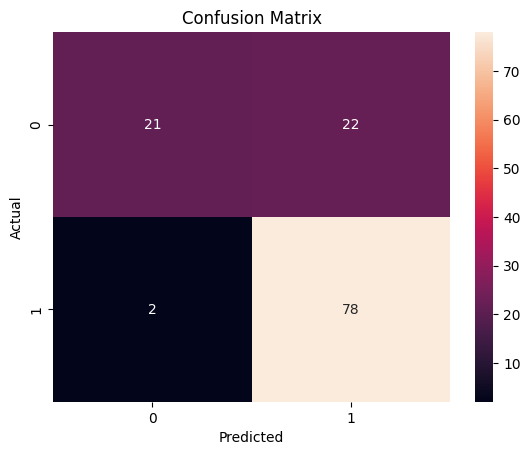

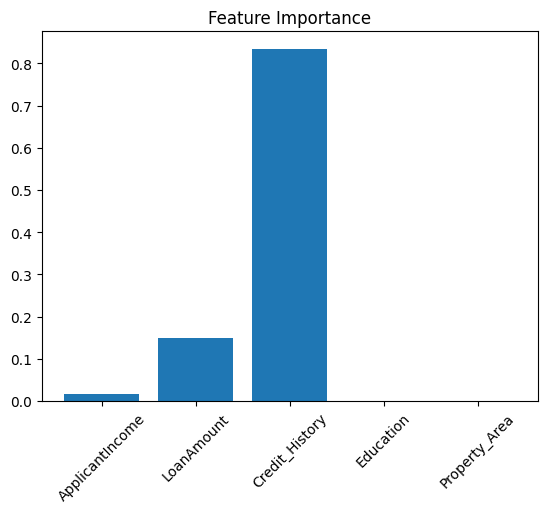

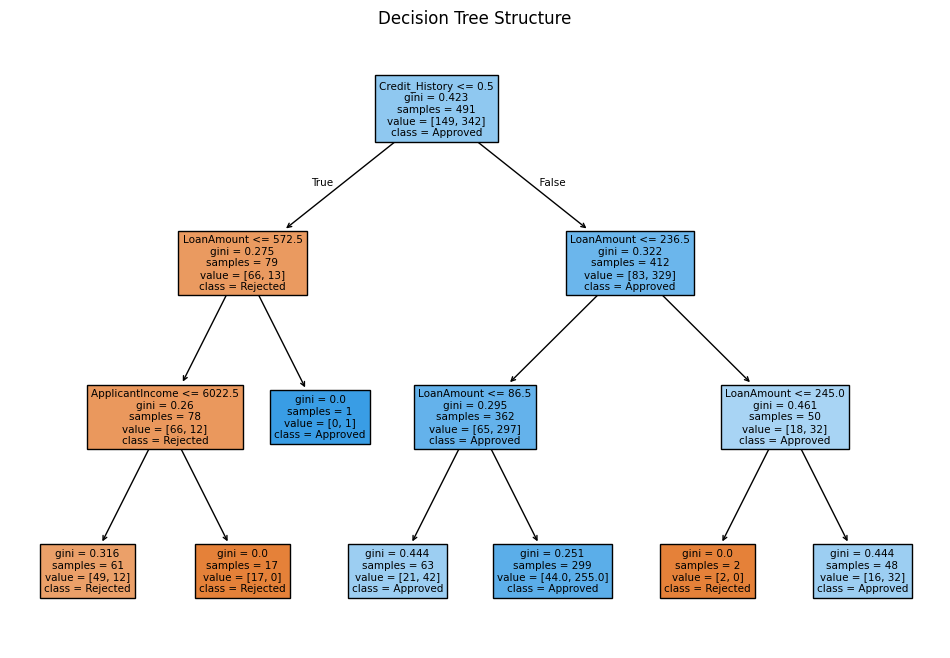

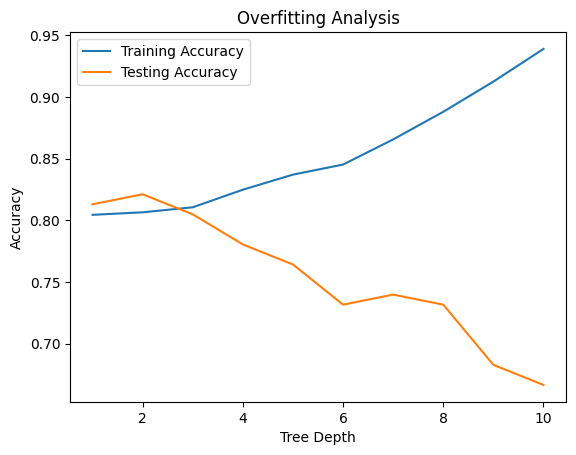

In [5]:
#from google.colab import files
#uploaded=files.upload()

# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("SASTHA JEYASRI A\n24BAD106")


# 2. Load Dataset
loan = pd.read_csv("decision_tree.csv")
print("Dataset Preview:")
print(loan.head())


# 3. Data Inspection
print("\nMissing Values:")
print(loan.isnull().sum())


# 4. Handle Missing Values
loan.fillna(method='ffill', inplace=True)


# 5. Encode Categorical Variables
le = LabelEncoder()
for col in loan.columns:
    if loan[col].dtype == 'object':
        loan[col] = le.fit_transform(loan[col])


# 6. Select Features and Target
X = loan[['ApplicantIncome',
          'LoanAmount',
          'Credit_History',
          'Education',
          'Property_Area']]

y = loan['Loan_Status']


# 7. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


# 8. Train Decision Tree Model
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)


# 9. Predict Loan Status
y_pred = dt.predict(X_test)


# 10. Performance Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# 11. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 12. Feature Importance Plot
importance = dt.feature_importances_

plt.figure()
plt.bar(X.columns, importance)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()


# 13. Decision Tree Structure
plt.figure(figsize=(12,8))
plot_tree(dt,
          feature_names=X.columns,
          class_names=["Rejected","Approved"],
          filled=True)
plt.title("Decision Tree Structure")
plt.show()


# 14. Overfitting Analysis (Tree Depth Experiment)
depths = range(1,11)
train_acc = []
test_acc = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))


# 15. Shallow vs Deep Tree Comparison
plt.figure()
plt.plot(depths, train_acc, label="Training Accuracy")
plt.plot(depths, test_acc, label="Testing Accuracy")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Analysis")
plt.legend()
plt.show()